# Poor accuracy of `conv()` and `@`

In [1]:
import numpy as np

from triqs.gf import MeshReTime, MeshProduct, Gf

from tddt.keldysh import KeldyshGF, from_lesser_greater, herm_conj, conv, Branch, ContourPoint

In [2]:
# Make Keldysh GF of a single fermion with energy `eps` and occupation number `n`
def make_g(eps, n, t_mesh):
    tt_mesh = MeshProduct(t_mesh, t_mesh)
    
    g_l = Gf(mesh=tt_mesh, target_shape=(1, 1))
    g_g = Gf(mesh=tt_mesh, target_shape=(1, 1))
    
    for t1, t2 in tt_mesh:
        g_g[t1, t2] = -1j * (1.0 - n) * np.exp(-1j * eps * (t1 - t2))
        g_l[t1, t2] = -1j * (-n) * np.exp(-1j * eps * (t1 - t2))
    
    return from_lesser_greater(g_l, g_g)

In [4]:
t_max = 1.0
N_t_range = range(11, 201, 10)

delta_list = []

for N_t in N_t_range:
    t_mesh = MeshReTime(0.0, t_max, N_t)

    # Make G1 and G2
    G1 = make_g(1.0, 0.1, t_mesh)
    G2 = make_g(1.5, 0.2, t_mesh)

    # Hermitian conjugate of contour convolution G1 * G2 
    G1G2_h = herm_conj(G1 @ G2)
    # Contour convolution of conjugates of G2 and G1
    G2_h_G1_h = herm_conj(G2) @ herm_conj(G1)
    
    diff = G1G2_h - G2_h_G1_h

    t0 = list(t_mesh)[0]
    z = ContourPoint(Branch.FORWARD, t0)
    # z is the t=0 point on the forward branch
    delta_list.append(np.abs(diff[z, z])[0, 0])

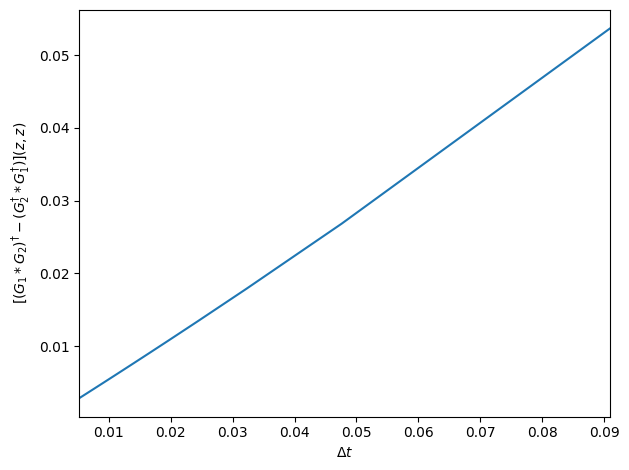

In [5]:
import matplotlib.pyplot as plt

dt_range = t_max / np.array(N_t_range)

plt.plot(dt_range, delta_list)
plt.xlim(dt_range[-1], dt_range[0])
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"$[(G_1 * G_2)^\dag - (G_2^\dag * G_1^\dag)](z, z)$")
plt.tight_layout()